# 03. Эксперименты

Базовые варианты:

1. **LogReg** (`class_weight=balanced`): линейная граница, интерпретируемые веса, устойчивый baseline
2. **Random Forest**: нелинейности, `class_weight`, важности признаков
3. **XGBoost** / **LightGBM**: бустинги на таблицах
4. **KNN** (`k=15`, веса по расстоянию): нелинейная граница по соседям
5. **Voting (soft)**: `RF + LightGBM + GBC` ансамбль с усреднением вероятностей

In [1]:
import sys
import warnings
from pathlib import Path

def _project_root() -> Path:
    here = Path.cwd().resolve()
    for i in [here, *here.parents]:
        if (i / 'src' / 'config.py').is_file():
            return i
    raise FileNotFoundError()

ROOT = _project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

try:
    import numpy as np
    import pandas as pd
    import matplotlib
    import matplotlib.pyplot as plt
    from sklearn.model_selection import cross_val_score
    from sklearn.metrics import auc, roc_curve
except ModuleNotFoundError as e:
    raise ModuleNotFoundError()
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')
else:
    matplotlib.use('module://matplotlib_inline.backend_inline')

import json
warnings.filterwarnings('ignore', category=UserWarning)
from src.config import RANDOM_STATE
from src.modeling import (
    classification_metrics,
    make_baseline_logistic,
    make_knn,
    make_lightgbm,
    make_random_forest,
    make_voting_ensemble,
    make_xgboost,
    pca_logistic_pipeline,
    run_randomized_search,
    stratified_kfold,
)
from src.preprocessing import full_pipeline

np.random.seed(RANDOM_STATE)
enc = full_pipeline(with_engineering=True)
X_tr, y_tr = enc.X_train, enc.y_train
X_va, y_va = enc.X_val, enc.y_val
X_te, y_te = enc.X_test, enc.y_test
cv = stratified_kfold()
FACTORIES = {
    'LogReg_balanced': make_baseline_logistic,
    'RandomForest': make_random_forest,
    'XGBoost': make_xgboost,
    'LightGBM': make_lightgbm,
    'KNN': make_knn,
    'Voting_soft': make_voting_ensemble,
}

In [2]:
rows = []
models = {i: FACTORIES[i]() for i in FACTORIES}

for i, j in models.items():
    s = cross_val_score(j, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
    j.fit(X_tr, y_tr)
    p_va = j.predict_proba(X_va)[:, 1] if hasattr(j, 'predict_proba') else None
    pr_va = j.predict(X_va)
    met = classification_metrics(y_va, pr_va, p_va)
    rows.append({
        'model': i,
        'cv_roc_auc_mean': s.mean(),
        'cv_roc_auc_std': s.std(),
        'val_roc_auc': met.get('roc_auc', float('nan')),
        'val_recall': met['recall'],
        'val_f1': met['f1'],
    })
res = pd.DataFrame(rows).sort_values('val_roc_auc', ascending=False)
res

,model,cv_roc_auc_mean,cv_roc_auc_std,val_roc_auc,val_recall,val_f1
0,LogReg_balanced,0.821806,0.053105,0.871894,0.789474,0.545455
1,RandomForest,0.793780,0.042554,0.864948,0.157895,0.266667
5,Voting_soft,0.798373,0.039619,0.850655,0.342105,0.481481
2,XGBoost,0.799329,0.037108,0.833823,0.342105,0.500000
3,LightGBM,0.789193,0.037106,0.818595,0.421053,0.524590
4,KNN,0.761589,0.049168,0.783396,0.052632,0.100000


## Что видно?

- По `val_roc_auc` лучше всего выглядит `LogReg_balanced`, пока она лучше ранжирует риск увольнения, чем остальные
- У `RandomForest` AUC неплохой, но `val_recall` очень низкий: модель плохо ловит класс `Attrition=1`, что может быть рискованно
- `XGBoost` и `LightGBM` дают более сбалансированное поведение, но пока ниже по AUC на validation


Тут нельзя ориентироваться только на `accuracy`: при дисбалансе классов важнее сочетание `roc_auc` и `recall` по увольняющимся

In [3]:
best_name = res.iloc[0]['model']
m_best = FACTORIES[best_name]()
m_best.fit(X_tr, y_tr)
p_te = m_best.predict_proba(X_te)[:, 1]
pr_te = m_best.predict(X_te)
print('Лучшая на val:', best_name)
print('Test:', classification_metrics(y_te, pr_te, p_te))

Лучшая на val: LogReg_balanced
Test: {'accuracy': 0.7491525423728813, 'precision': 0.3411764705882353, 'recall': 0.6170212765957447, 'f1': 0.4393939393939394, 'roc_auc': 0.7674159231297185}


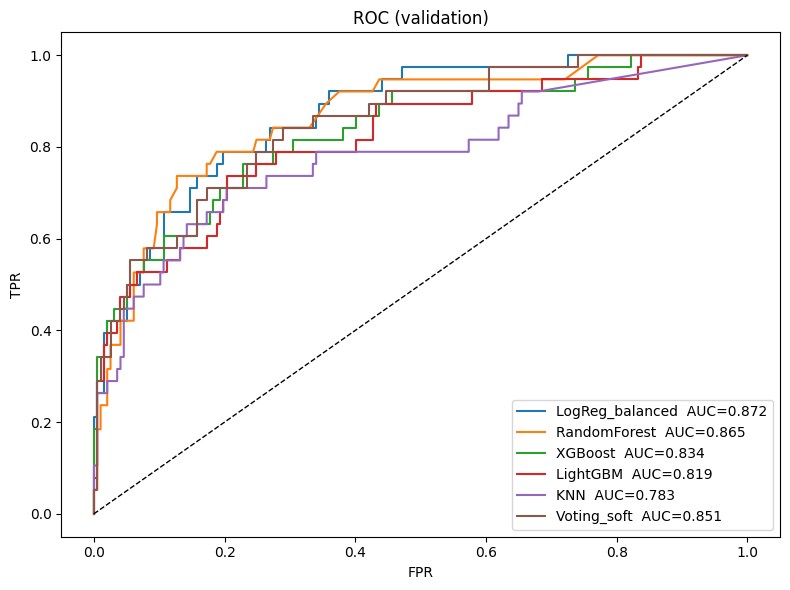

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, j in FACTORIES.items():
    m = j()
    m.fit(X_tr, y_tr)
    y_score = m.predict_proba(X_va)[:, 1]
    fpr, tpr, _ = roc_curve(y_va, y_score)
    ax.plot(fpr, tpr, label=f'{i}  AUC={auc(fpr, tpr):.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend(loc='lower right')
ax.set_title('ROC (validation)')
plt.tight_layout()
plt.show()

## Гиперпараметрический поиск и уменьшение размерности

Проверим две гипотезы:

1. `RandomForest` с подбором гиперпараметров (RandomizedSearchCV) улучшит ROC-AUC и Recall
2. PCA + LogReg даст более устойчивое обобщение без сильной потери качества

Итог сравним с предыдущими

In [5]:
rf_search = run_randomized_search(
    make_random_forest(),
    {
        'n_estimators': [200, 300, 500, 700],
        'max_depth': [None, 4, 6, 8, 12],
        'min_samples_leaf': [1, 2, 4, 8],
        'min_samples_split': [2, 5, 10],
    },
    X_tr,
    y_tr,
    n_iter=20,
)

rf_best = rf_search.best_estimator_
rf_val = classification_metrics(y_va, rf_best.predict(X_va), rf_best.predict_proba(X_va)[:, 1])
rf_test = classification_metrics(y_te, rf_best.predict(X_te), rf_best.predict_proba(X_te)[:, 1])
print('RF tuned best params:', rf_search.best_params_)

RF tuned best params: {'n_estimators': 700, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_depth': 6}


In [6]:
pca_lr = pca_logistic_pipeline(0.95)
pca_lr.fit(X_tr, y_tr)
pca_val = classification_metrics(y_va, pca_lr.predict(X_va), pca_lr.predict_proba(X_va)[:, 1])
pca_test = classification_metrics(y_te, pca_lr.predict(X_te), pca_lr.predict_proba(X_te)[:, 1])

extra = pd.DataFrame(
    [
        {
            'model': 'RandomForest_tuned',
            'val_roc_auc': rf_val['roc_auc'],
            'val_recall': rf_val['recall'],
            'val_f1': rf_val['f1'],
            'test_roc_auc': rf_test['roc_auc'],
            'test_recall': rf_test['recall'],
            'test_f1': rf_test['f1'],
            'note': str(rf_search.best_params_),
        },
        {
            'model': 'PCA95+LogReg',
            'val_roc_auc': pca_val['roc_auc'],
            'val_recall': pca_val['recall'],
            'val_f1': pca_val['f1'],
            'test_roc_auc': pca_test['roc_auc'],
            'test_recall': pca_test['recall'],
            'test_f1': pca_test['f1'],
            'note': 'PCA(n_components=0.95)',
        },
    ]
)

## Визуализация PCA

Проекция на две компоненты для наглядности разделения классов

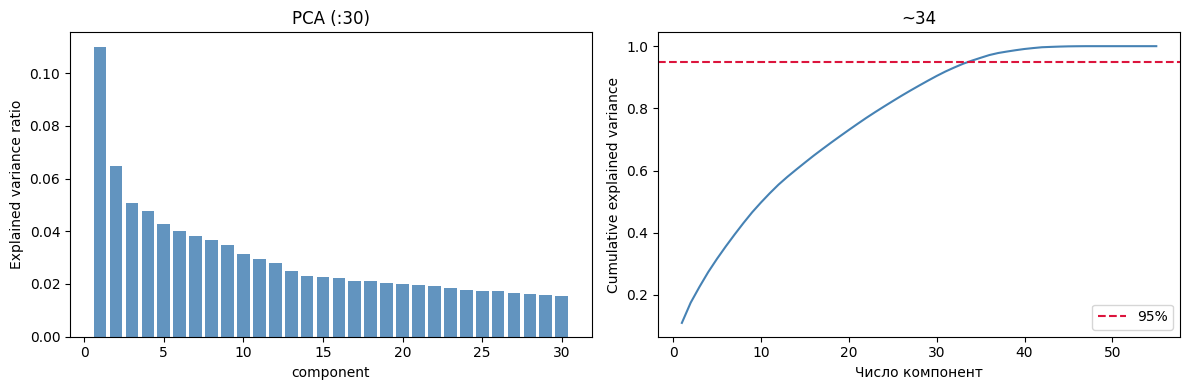

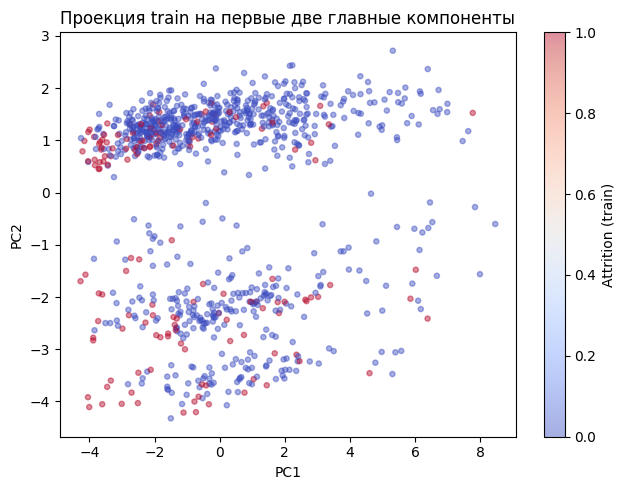

In [8]:
from sklearn.decomposition import PCA

scaler2 = pca_lr.named_steps['scaler2']
X_tr_scaled = scaler2.transform(X_tr)
pca_all = PCA(n_components=None, random_state=RANDOM_STATE)
pca_all.fit(X_tr_scaled)
evr = pca_all.explained_variance_ratio_
cum = np.cumsum(evr)
n95 = int(np.searchsorted(cum, 0.95)) + 1
k = min(30, len(evr))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(1, k + 1), evr[:k], color='steelblue', alpha=0.85)
axes[0].set_xlabel('component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('PCA (:30)')
axes[1].plot(np.arange(1, len(cum) + 1), cum, color='steelblue')
axes[1].axhline(0.95, color='crimson', ls='--', label='95%')
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title(f'~{n95}')
axes[1].legend()
plt.tight_layout()
plt.show()

Z2 = pca_all.transform(X_tr_scaled)[:, :2]
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=y_tr, alpha=0.45, cmap='coolwarm', s=14)
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Attrition (train)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Проекция train на первые две главные компоненты')
plt.tight_layout()
plt.show()

In [9]:
summary_all = (
    pd.concat(
        [
            res[['model', 'val_roc_auc', 'val_recall', 'val_f1']].assign(test_roc_auc=np.nan, test_recall=np.nan, test_f1=np.nan, note='base'),
            extra,
        ],
        ignore_index=True,
    )
    .sort_values(['val_roc_auc', 'val_recall'], ascending=False)
    .reset_index(drop=True)
)
summary_all

,model,val_roc_auc,val_recall,val_f1,test_roc_auc,test_recall,test_f1,note
0,RandomForest_tuned,0.874165,0.578947,0.556962,0.720745,0.361702,0.365591,"{'n_estimators': 700, 'min_samples_split': 10,..."
1,LogReg_balanced,0.871894,0.789474,0.545455,NaN,NaN,NaN,base
2,RandomForest,0.864948,0.157895,0.266667,NaN,NaN,NaN,base
3,PCA95+LogReg,0.853193,0.736842,0.500000,0.775223,0.638298,0.483871,PCA(n_components=0.95)
4,Voting_soft,0.850655,0.342105,0.481481,NaN,NaN,NaN,base
5,XGBoost,0.833823,0.342105,0.500000,NaN,NaN,NaN,base
6,LightGBM,0.818595,0.421053,0.524590,NaN,NaN,NaN,base
7,KNN,0.783396,0.052632,0.100000,NaN,NaN,NaN,base


In [10]:
f_row = summary_all.iloc[0]
print('Итоговая модель:', f_row['model'])

if f_row['model'] == 'RandomForest_tuned':
    final_model = rf_best
elif f_row['model'] == 'PCA95+LogReg':
    final_model = pca_lr
else:
    final_model = FACTORIES[f_row['model']]()
    final_model.fit(X_tr, y_tr)

f_test = classification_metrics(y_te, final_model.predict(X_te), final_model.predict_proba(X_te)[:, 1])
print('Test final:', f_test)

Итоговая модель: RandomForest_tuned
Test final: {'accuracy': 0.8, 'precision': 0.3695652173913043, 'recall': 0.3617021276595745, 'f1': 0.3655913978494624, 'roc_auc': 0.7207446808510638}


## Вывод

- Лучшей выбрана модель с максимальным `val_roc_auc`, при этом дополнительно контролируем `recall` класса `Attrition=1`
- По текущим результатам tuned-версия `RandomForest` дает лучший баланс между качеством ранжирования и полнотой обнаружения на validation

Сохраним итоговую модель

In [11]:
from joblib import dump

models_dir = ROOT / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / f'final_model.joblib'
meta_path = models_dir / f'final_model.json'
_dump_result = dump(final_model, model_path)
meta = {
    'selected_model': str(f_row['model']),
    'selection_priority': ['val_roc_auc', 'val_recall'],
    'test_metrics': f_test,
    'model_file': model_path.name,
}
meta_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8')

330